# 04e — Basis Vectors and Matrix Columns

## Purpose

Understand a matrix as a transformation of the standard basis vectors.

The key idea is:
<p style="text-align: center; font-weight:700">
The columns of a matrix tell us where the basis vectors land.
</p>

Once we understand that, matrix-vector multiplication becomes less mysterious:

<p style="text-align: center;">
$\mathbf{v} = x\mathbf{e}_1 + y\mathbf{e}_2$
</p>

For a vector $\mathbf{v} = (x, y)$, the matrix does not treat the vector as an isolated arrow. It transforms the basis vectors, then rebuilds the vector using the same coefficients.

## Setup

We will use NumPy for the calculations and Matplotlib for the plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Plotting helpers

These helpers keep the examples focused on the maths rather than repeated plotting code.

In [2]:
def setup_axis(ax, title, limit=4):
    """Prepare a simple 2D coordinate axis."""
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_vector(ax, vector, label, start=(0, 0), linewidth=2, linestyle="-", alpha=1.0):
    """Draw a vector arrow from a starting point."""
    start = np.array(start, dtype=float)
    vector = np.array(vector, dtype=float)

    ax.arrow(
        start[0],
        start[1],
        vector[0],
        vector[1],
        head_width=0.12,
        head_length=0.18,
        length_includes_head=True,
        linewidth=linewidth,
        linestyle=linestyle,
        alpha=alpha,
    )

    end = start + vector
    ax.text(end[0] + 0.08, end[1] + 0.08, label, fontsize=11)


def draw_chain(ax, first, second, first_label, second_label, result_label):
    """Show vector addition by placing the second vector at the end of the first."""
    first = np.array(first, dtype=float)
    second = np.array(second, dtype=float)
    result = first + second

    draw_vector(ax, first, first_label, linewidth=2)
    draw_vector(ax, second, second_label, start=first, linewidth=2, linestyle="--")
    draw_vector(ax, result, result_label, linewidth=3)


def print_vector(name, vector):
    """Print a vector in a compact notebook-friendly format."""
    print(f"{name} = [{vector[0]: .2f}, {vector[1]: .2f}]")

## The standard basis vectors

In 2D, the standard basis vectors are the two ordinary one-step directions:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

$\mathbf{e}_1$ points one step along the x-axis.  
$\mathbf{e}_2$ points one step along the y-axis.

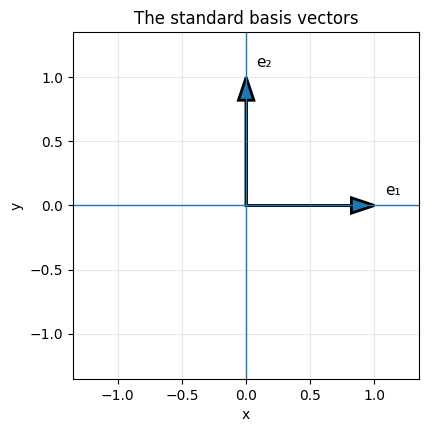

In [3]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4.5))

setup_axis(
    ax,
    "The standard basis vectors",
    limit=1.35
)

draw_vector(ax, e1, "e₁")
draw_vector(ax, e2, "e₂")

plt.show()

## A vector as a recipe using the basis vectors

Consider this vector:

$$
\mathbf{v} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

Its coordinates tell us how to build it from the standard basis vectors:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

So the vector is not just an arrow. It is also a set of instructions:

> take 2 steps in the $\mathbf{e}_1$ direction and 1 step in the $\mathbf{e}_2$ direction.

In [4]:
v = np.array([2, 1])

v_from_basis = 2 * e1 + 1 * e2

print_vector("v", v)
print_vector("2e1 + 1e2", v_from_basis)
print("Same result?", np.array_equal(v, v_from_basis))

v = [ 2.00,  1.00]
2e1 + 1e2 = [ 2.00,  1.00]
Same result? True


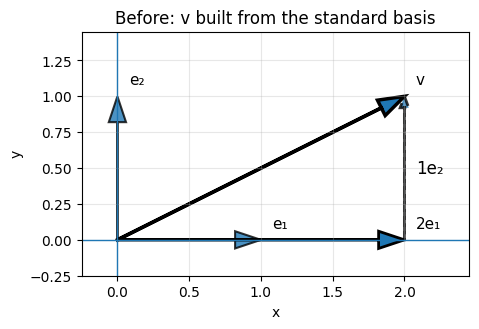

In [5]:
v = np.array([2, 1])

fig, ax = plt.subplots(figsize=(5, 4))

setup_axis(
    ax,
    "Before: v built from the standard basis",
    limit=1
)

# This example is almost entirely in the positive quadrant, so use asymmetric
# limits rather than wasting space on the bottom-left quadrant.
ax.set_xlim(-0.25, 2.45)
ax.set_ylim(-0.25, 1.45)

# Standard basis vectors.
draw_vector(ax, e1, "e₁", linewidth=1.5, alpha=0.8)
draw_vector(ax, e2, "e₂", linewidth=1.5, alpha=0.8)

# Construction steps: 2e₁, then 1e₂.
draw_vector(ax, 2 * e1, "2e₁", linewidth=2)

ax.arrow(
    2,
    0,
    0,
    1,
    length_includes_head=True,
    head_width=0.06,
    head_length=0.08,
    linewidth=2,
    linestyle="--",
    alpha=0.8
)

ax.text(
    2.08,
    0.5,
    "1e₂",
    fontsize=12,
    ha="left",
    va="center"
)

# Final vector.
draw_vector(ax, v, "v", linewidth=2.5)

plt.show()

## A matrix transforms the basis vectors

Now define a matrix:

$$
A =
\begin{bmatrix}
1.5 & -0.8 \\
0.6 & 1.2
\end{bmatrix}
$$

The columns of this matrix tell us where the standard basis vectors land.

The first column is $A\mathbf{e}_1$:

$$
A\mathbf{e}_1 =
\begin{bmatrix}
1.5 \\
0.6
\end{bmatrix}
$$

The second column is $A\mathbf{e}_2$:

$$
A\mathbf{e}_2 =
\begin{bmatrix}
-0.8 \\
1.2
\end{bmatrix}
$$

So this matrix sends:

$$
\mathbf{e}_1 \mapsto A\mathbf{e}_1
\qquad
\mathbf{e}_2 \mapsto A\mathbf{e}_2
$$

In [6]:
A = np.array([
    [1.5, -0.8],
    [0.6,  1.2],
])

Ae1 = A @ e1
Ae2 = A @ e2

print("A =")
print(A)
print()
print_vector("A @ e1", Ae1)
print_vector("A @ e2", Ae2)
print()
print_vector("first column of A", A[:, 0])
print_vector("second column of A", A[:, 1])

A =
[[ 1.5 -0.8]
 [ 0.6  1.2]]

A @ e1 = [ 1.50,  0.60]
A @ e2 = [-0.80,  1.20]

first column of A = [ 1.50,  0.60]
second column of A = [-0.80,  1.20]


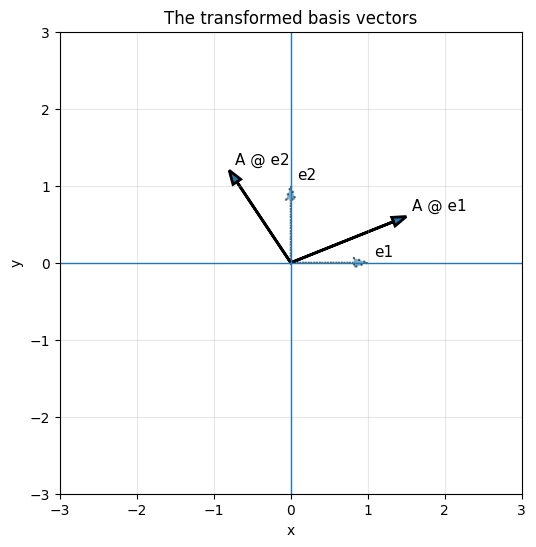

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
setup_axis(ax, "The transformed basis vectors", limit=3)

draw_vector(ax, e1, "e1", linewidth=1.5, linestyle=":", alpha=0.6)
draw_vector(ax, e2, "e2", linewidth=1.5, linestyle=":", alpha=0.6)
draw_vector(ax, Ae1, "A @ e1")
draw_vector(ax, Ae2, "A @ e2")

plt.show()

## Matrix-vector multiplication as rebuilding the vector

Our original vector was:

\[
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
\]

After applying \(A\), the coefficients do not change:

\[
A\mathbf{v} = 2(A\mathbf{e}_1) + 1(A\mathbf{e}_2)
\]

The matrix changes the basis vectors. The vector follows because it is built from those basis vectors.

In [8]:
Av = A @ v
Av_from_transformed_basis = 2 * Ae1 + 1 * Ae2

print_vector("A @ v", Av)
print_vector("2(A @ e1) + 1(A @ e2)", Av_from_transformed_basis)
print("Same result?", np.allclose(Av, Av_from_transformed_basis))

A @ v = [ 2.20,  2.40]
2(A @ e1) + 1(A @ e2) = [ 2.20,  2.40]
Same result? True


## Before and after

The next pair of plots shows the same vector recipe before and after the transformation.

Before:

\[
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
\]

After:

\[
A\mathbf{v} = 2(A\mathbf{e}_1) + 1(A\mathbf{e}_2)
\]

The coefficients are the same. The basis vectors have moved.

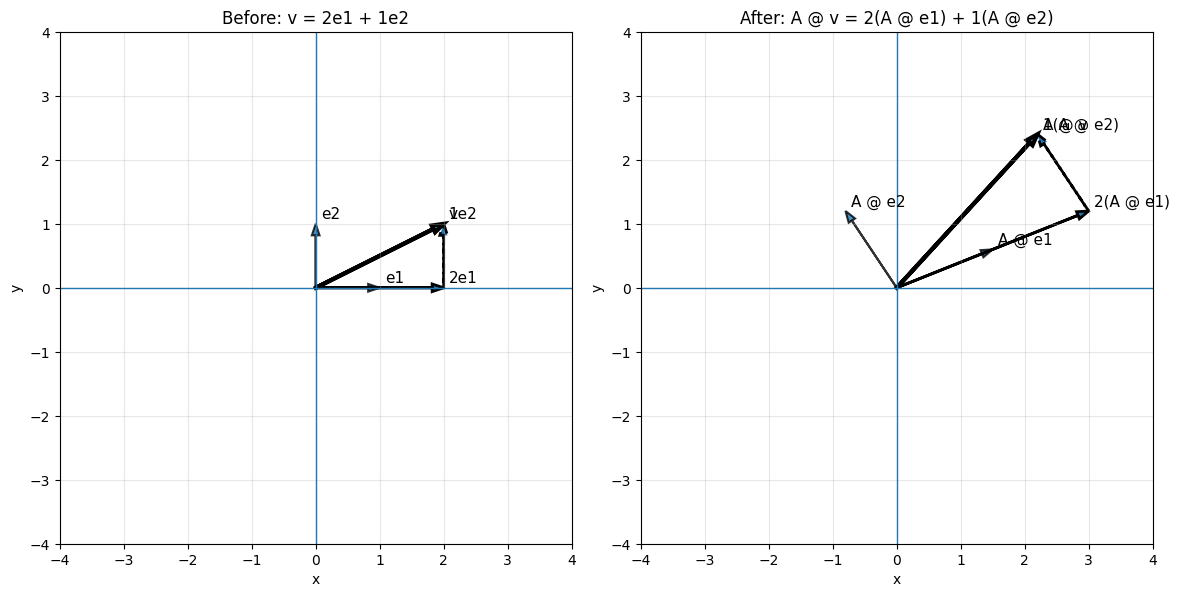

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Before
setup_axis(axes[0], "Before: v = 2e1 + 1e2", limit=4)
draw_vector(axes[0], e1, "e1", linewidth=1.5, alpha=0.8)
draw_vector(axes[0], e2, "e2", linewidth=1.5, alpha=0.8)
draw_chain(axes[0], 2 * e1, 1 * e2, "2e1", "1e2", "v")

# After
setup_axis(axes[1], "After: A @ v = 2(A @ e1) + 1(A @ e2)", limit=4)
draw_vector(axes[1], Ae1, "A @ e1", linewidth=1.5, alpha=0.8)
draw_vector(axes[1], Ae2, "A @ e2", linewidth=1.5, alpha=0.8)
draw_chain(axes[1], 2 * Ae1, 1 * Ae2, "2(A @ e1)", "1(A @ e2)", "A @ v")

plt.tight_layout()
plt.show()

## Reading the matrix by columns

Because the columns show where the basis vectors land, we can read this matrix geometrically:

\[
A = \begin{bmatrix}
1.5 & -0.8 \\
0.6 & 1.2
\end{bmatrix}
\]

The first column says:

\[
\mathbf{e}_1 \mapsto \begin{bmatrix}1.5 \\ 0.6\end{bmatrix}
\]

The second column says:

\[
\mathbf{e}_2 \mapsto \begin{bmatrix}-0.8 \\ 1.2\end{bmatrix}
\]

So multiplying by \(A\) means rebuilding every vector using those new basis directions.

In [10]:
columns = [A[:, 0], A[:, 1]]

for index, column in enumerate(columns, start=1):
    print_vector(f"Column {index}", column)

Column 1 = [ 1.50,  0.60]
Column 2 = [-0.80,  1.20]


## A second vector

To check that this is not a special trick for \([2, 1]\), try another vector:

\[
\mathbf{w} = \begin{bmatrix}-1 \\ 2\end{bmatrix}
\]

That means:

\[
\mathbf{w} = -1\mathbf{e}_1 + 2\mathbf{e}_2
\]

After the transformation:

\[
A\mathbf{w} = -1(A\mathbf{e}_1) + 2(A\mathbf{e}_2)
\]

In [11]:
w = np.array([-1, 2])

Aw = A @ w
Aw_from_transformed_basis = -1 * Ae1 + 2 * Ae2

print_vector("A @ w", Aw)
print_vector("-1(A @ e1) + 2(A @ e2)", Aw_from_transformed_basis)
print("Same result?", np.allclose(Aw, Aw_from_transformed_basis))

A @ w = [-3.10,  1.80]
-1(A @ e1) + 2(A @ e2) = [-3.10,  1.80]
Same result? True


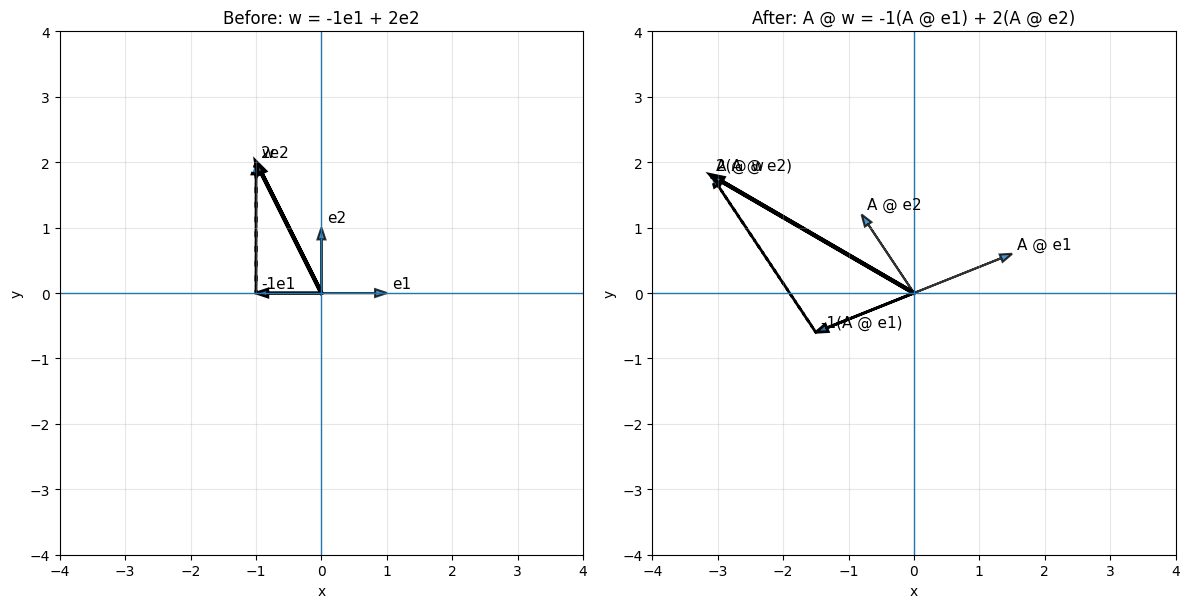

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Before
setup_axis(axes[0], "Before: w = -1e1 + 2e2", limit=4)
draw_vector(axes[0], e1, "e1", linewidth=1.5, alpha=0.8)
draw_vector(axes[0], e2, "e2", linewidth=1.5, alpha=0.8)
draw_chain(axes[0], -1 * e1, 2 * e2, "-1e1", "2e2", "w")

# After
setup_axis(axes[1], "After: A @ w = -1(A @ e1) + 2(A @ e2)", limit=4)
draw_vector(axes[1], Ae1, "A @ e1", linewidth=1.5, alpha=0.8)
draw_vector(axes[1], Ae2, "A @ e2", linewidth=1.5, alpha=0.8)
draw_chain(axes[1], -1 * Ae1, 2 * Ae2, "-1(A @ e1)", "2(A @ e2)", "A @ w")

plt.tight_layout()
plt.show()

## Why this matters for machine learning

Matrices appear everywhere in machine learning.

They can represent:

- transformations of data
- feature projections
- linear layers in neural networks
- changes of coordinate systems
- collections of learned weights

The important habit is to stop seeing matrix multiplication as only a mechanical calculation.

A matrix can also be read as a transformation:

> it moves the basis vectors, then every other vector follows from that movement.

## Summary

- The standard basis vectors are \(\mathbf{e}_1 = [1, 0]\) and \(\mathbf{e}_2 = [0, 1]\).
- A vector \([x, y]\) can be read as \(x\mathbf{e}_1 + y\mathbf{e}_2\).
- The first column of a matrix is where \(\mathbf{e}_1\) lands.
- The second column of a matrix is where \(\mathbf{e}_2\) lands.
- Matrix-vector multiplication rebuilds the vector using the transformed basis vectors.
- The coefficients stay the same; the basis vectors change.

The central idea:

\[
A\begin{bmatrix}x \\ y\end{bmatrix}
=
x(A\mathbf{e}_1) + y(A\mathbf{e}_2)
\]